## ANN MODEL

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras


In [3]:
# Load datasets and assign 'generalCategory' for coffee shops
df_coffee = pd.read_csv("final_coffeeshops_dataset_cleaned.csv")
if 'generalCategory' not in df_coffee.columns:
    df_coffee['generalCategory'] = 'coffee shop'

df_restaurant = pd.read_csv("final_restaurants_dataset_cleaned.csv")

# Unify local competition and average rating features names for both dataset
coffee_rename_map = {
    "Competition - Coffee Shops/Area": "Competition - Business Type/Area",
    "Competition - Coffee Shops/POI Density": "Competition - Business Type/POI Density",
    "Competition - Coffee Shops/related POIs": "Competition - Business Type/related POIs",
    "Avg Rating - Coffee Shops": "Avg Rating - Business Type"
}

restaurant_rename_map = {
    "Competition - Restaurants/Area": "Competition - Business Type/Area",
    "Competition - Restaurants/POI Density": "Competition - Business Type/POI Density",
    "Competition - Restaurants/related POIs": "Competition - Business Type/related POIs",
    "Avg Rating - Restaurants": "Avg Rating - Business Type"
}

df_coffee.rename(columns=coffee_rename_map, inplace=True)
df_restaurant.rename(columns=restaurant_rename_map, inplace=True)

# Combine datasets
df = pd.concat([df_coffee, df_restaurant], ignore_index=True)
#df = df_restaurant
#df = df_coffee
df['generalCategory'] = df['generalCategory'].map({'restaurant': 1, 'coffee shop': 0}).fillna(-1)

In [5]:
# Drop irrelevant columns
drop_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/POI Densit', 'Competition - Business Type/related POIs'
               , 'Competition - Food & Dining/POI Density']
df.drop(columns=drop_columns, inplace=True, errors='ignore')

In [7]:
# Convert categorical columns to numeric
df = df.apply(lambda col: col.astype('category') if col.dtypes == 'object' else col)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1910 entries, 0 to 1909
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Popularity                                1910 non-null   float64
 1   generalCategory                           1910 non-null   int64  
 2   Religious Institutions                    1910 non-null   int64  
 3   Coffee Shops                              1910 non-null   int64  
 4   Food & Dining                             1910 non-null   int64  
 5   Restaurants                               1910 non-null   int64  
 6   Home & Construction Services              1910 non-null   int64  
 7   Entertainment & Recreation                1910 non-null   int64  
 8   Retail & Shopping                         1910 non-null   int64  
 9   Finance & Services                        1910 non-null   int64  
 10  Education                           

In [9]:
#Test each competition factor separately and output the results to help you identify which one gives the best performance.
competition_columns = [
    'Competition - Business Type/Area',
    'Competition - Business Type/POI Density',
    'Competition - Business Type/related POIs',
    'Competition - Food & Dining/Area',
    'Competition - Food & Dining/POI Density',
    'Competition - Food & Dining/related POIs'
]

In [11]:
# Helper Functions to remove outliers and highly correlated features

def remove_outliers(X, y):
    """Remove outliers using IQR."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

    
# Remove Highly Correlated Features (Modified)
removed_corr_features = []  # List to store removed features

def remove_highly_correlated_features(X, threshold=0.95):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

<class 'pandas.core.frame.DataFrame'>
Index: 1709 entries, 0 to 1909
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Popularity                                1709 non-null   float64
 1   generalCategory                           1709 non-null   int64  
 2   Religious Institutions                    1709 non-null   int64  
 3   Coffee Shops                              1709 non-null   int64  
 4   Food & Dining                             1709 non-null   int64  
 5   Restaurants                               1709 non-null   int64  
 6   Home & Construction Services              1709 non-null   int64  
 7   Entertainment & Recreation                1709 non-null   int64  
 8   Retail & Shopping                         1709 non-null   int64  
 9   Finance & Services                        1709 non-null   int64  
 10  Education                                

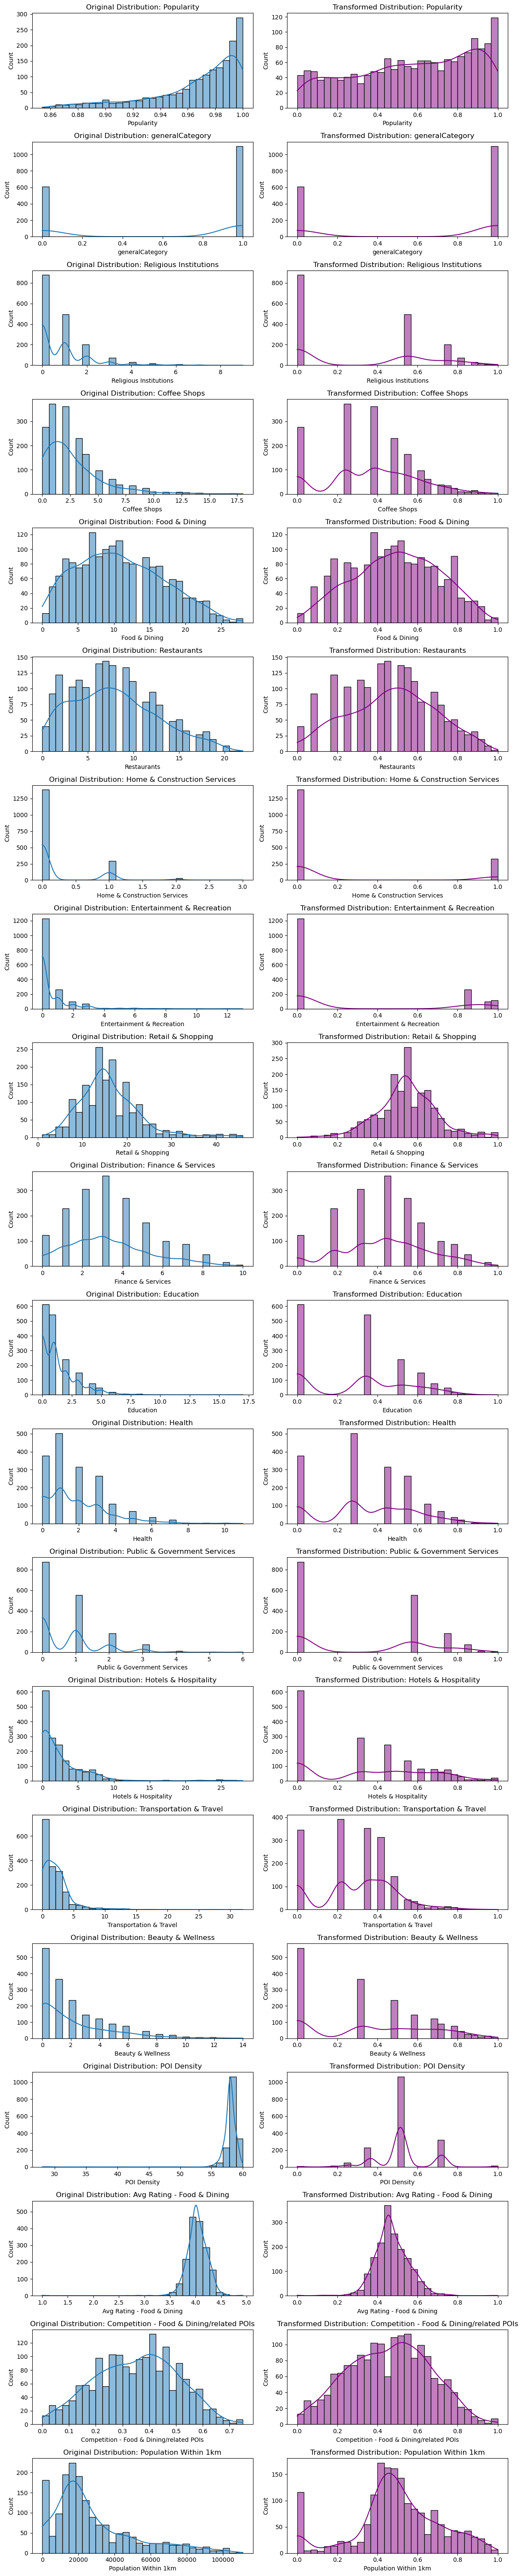


Shapiro-Wilk Normality Test Results:
                                         Shapiro-Wilk Test Statistic p-value  \
Popularity                                                  0.941258     0.0   
generalCategory                                             0.605886     0.0   
Religious Institutions                                      0.760322     0.0   
Coffee Shops                                                0.948158     0.0   
Food & Dining                                               0.986557     0.0   
Restaurants                                                  0.98381     0.0   
Home & Construction Services                                0.479157     0.0   
Entertainment & Recreation                                  0.584778     0.0   
Retail & Shopping                                           0.985463     0.0   
Finance & Services                                          0.967702     0.0   
Education                                                   0.859348     0.0   
He

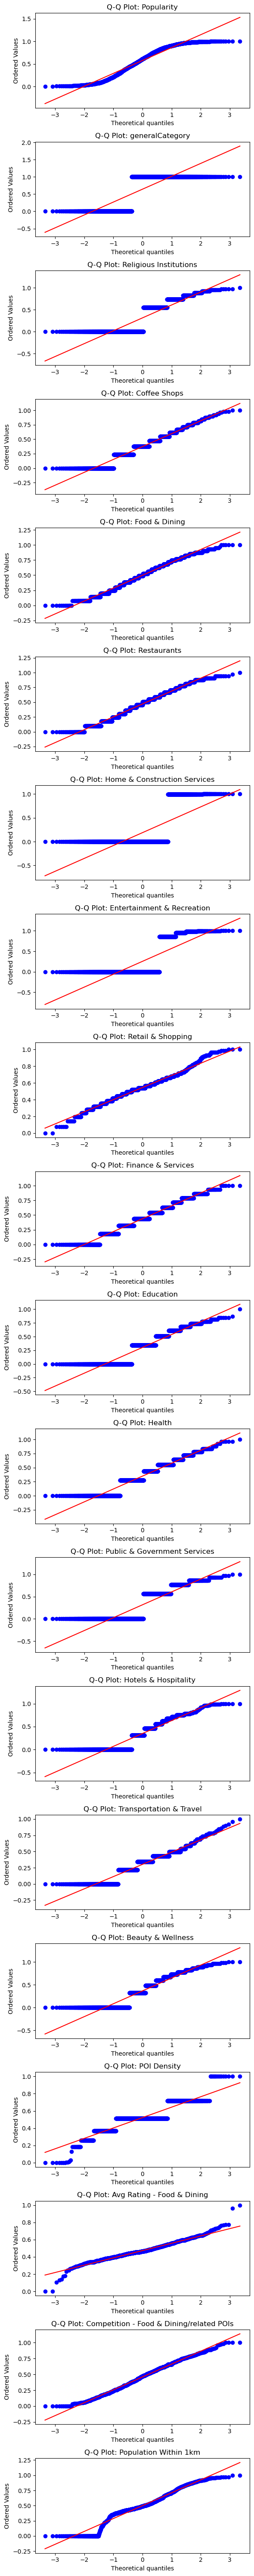

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Copy DataFrame
transformed_df = df.copy()

# Remove outliers in 'Popularity' using IQR method
Q1 = transformed_df['Popularity'].quantile(0.25)
Q3 = transformed_df['Popularity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()
# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
print("\nShapiro-Wilk Normality Test Results:")
print(normality_df)

# Optionally, save results to a CSV file
normality_df.to_csv("normality_test_results.csv", index=True)

# Q-Q Plots for each transformed feature
fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    probplot(transformed_df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}")

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 1709 entries, 0 to 1909
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Popularity                                1709 non-null   float64
 1   generalCategory                           1709 non-null   int64  
 2   Religious Institutions                    1709 non-null   int64  
 3   Coffee Shops                              1709 non-null   int64  
 4   Food & Dining                             1709 non-null   int64  
 5   Restaurants                               1709 non-null   int64  
 6   Home & Construction Services              1709 non-null   int64  
 7   Entertainment & Recreation                1709 non-null   int64  
 8   Retail & Shopping                         1709 non-null   int64  
 9   Finance & Services                        1709 non-null   int64  
 10  Education                                

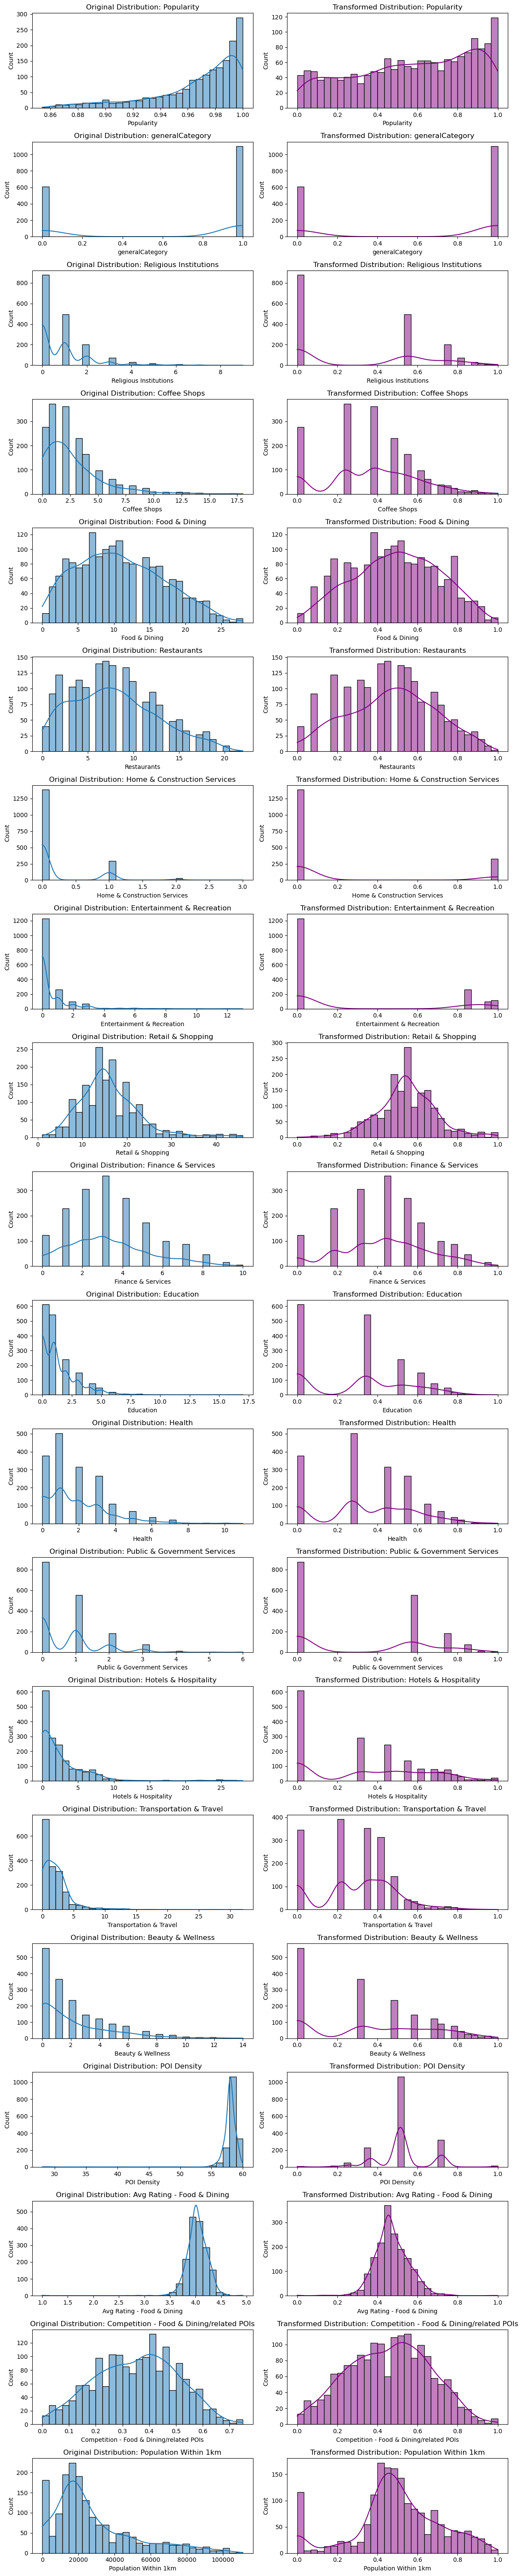


Shapiro-Wilk Normality Test Results:
                                         Shapiro-Wilk Test Statistic p-value  \
Popularity                                                  0.941258     0.0   
generalCategory                                             0.605886     0.0   
Religious Institutions                                      0.760322     0.0   
Coffee Shops                                                0.948158     0.0   
Food & Dining                                               0.986557     0.0   
Restaurants                                                  0.98381     0.0   
Home & Construction Services                                0.479157     0.0   
Entertainment & Recreation                                  0.584778     0.0   
Retail & Shopping                                           0.985463     0.0   
Finance & Services                                          0.967702     0.0   
Education                                                   0.859348     0.0   
He

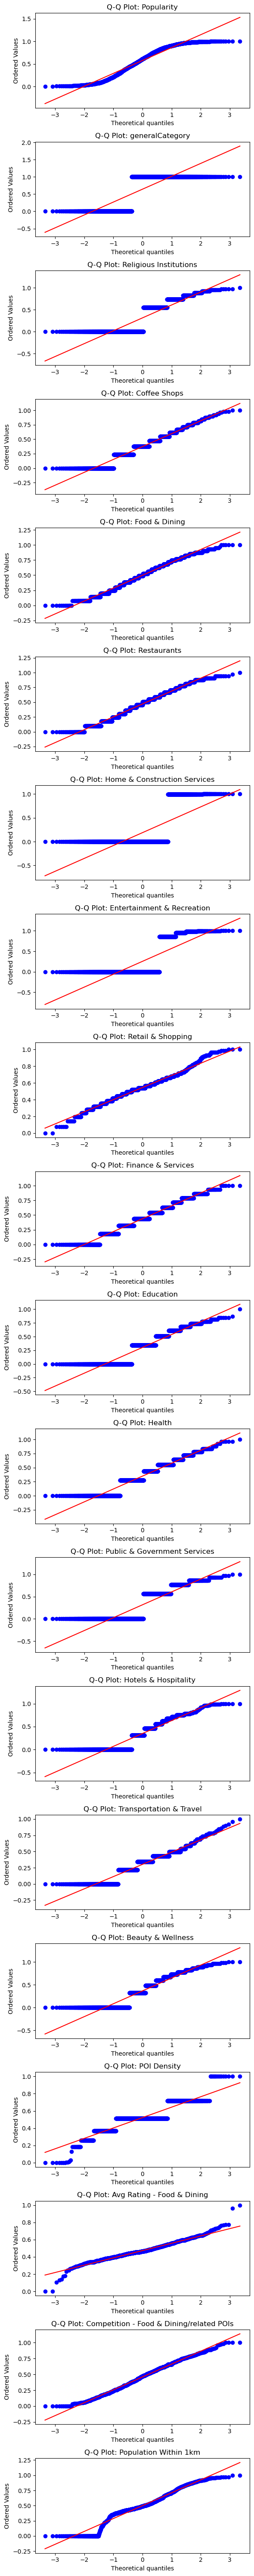

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Copy DataFrame
transformed_df = df.copy()

# Remove outliers in 'Popularity' using IQR method
Q1 = transformed_df['Popularity'].quantile(0.25)
Q3 = transformed_df['Popularity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()
# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
print("\nShapiro-Wilk Normality Test Results:")
print(normality_df)

# Optionally, save results to a CSV file
normality_df.to_csv("normality_test_results.csv", index=True)

# Q-Q Plots for each transformed feature
fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    probplot(transformed_df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}")

plt.tight_layout()
plt.show()

# Experiment 1 (MinMax)

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
import keras_tuner as kt

# Load Data (Assuming df is already loaded)
target = "Popularity"
X = transformed_df.drop(columns=[target])
y = transformed_df[target]

# Step 1: Remove Outliers (if needed)
num_outliers_before = X.shape[0]
X, y = remove_outliers(X, y)
num_outliers_removed = num_outliers_before - X.shape[0]
print(f"Number of data points removed as outliers: {num_outliers_removed}")

# Step 2: Remove Highly Correlated Features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")

# Step 3: Apply MinMax Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # No leakage since PCA & training happen later

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores, mse_scores, r2_scores, rmse_scores = [], [], [], []

# Function to Build ANN Model with Hyperparameter Tuning
def build_model(hp):
    model = keras.Sequential([
        Dense(hp.Int('units_1', min_value=64, max_value=256, step=32), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_1', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)),
        Dense(hp.Int('units_2', min_value=32, max_value=128, step=16), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_2', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)),
        Dense(1)  # Regression output layer (Linear activation)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='LOG')),
                  loss='mse', metrics=['mae'])
    return model

# Use KerasTuner for Hyperparameter Optimization
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,  # Adjust for deeper tuning
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='ANN_Tuning'
)

# Perform K-Fold Cross-Validation
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Step 4: Apply PCA **Only on Training Data**
    pca = PCA(n_components=0.95)  # Retain 95% variance
    X_train_pca = pca.fit_transform(X_train)  # Fit PCA only on training set
    X_test_pca = pca.transform(X_test)  # Transform test set using trained PCA model

    # Find Best Hyperparameters using KerasTuner
    tuner.search(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Train Final Model with Best Hyperparameters
    best_model = tuner.hypermodel.build(best_hp)
    best_model.fit(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

    # Evaluate Model
    y_pred_nn = best_model.predict(X_test_pca).flatten()
    mae_scores.append(mean_absolute_error(y_test, y_pred_nn))
    mse_scores.append(mean_squared_error(y_test, y_pred_nn))
    r2_scores.append(r2_score(y_test, y_pred_nn))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_nn)))

# Print Final Performance Metrics
print("\n🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:")
print(f"MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"R²: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")

# Print Final Model Summary
print("\n🛠️ Optimized ANN Model Summary:")
best_model.summary()


Number of data points removed as outliers: 0
Removed highly correlated features: ['Restaurants']
Reloading Tuner from hyperparam_tuning\ANN_Tuning\tuner0.json
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:
MAE: 0.2506 ± 0.0063
MSE: 0.0901 ± 0.0029
R²: -0.0454 ± 0.0438
RMSE: 0.3001 ± 0.0049

🛠️ Optimized ANN Model Summary:


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 96)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,133 (94.27 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 15,876 (62.02 KB)

# Experiment 2 (MinMax)

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
import keras_tuner as kt

# Load Data (Assuming df is already loaded)

X = transformed_df[['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']]
y = transformed_df['Popularity']

# Step 1: Remove Outliers (if needed)
num_outliers_before = X.shape[0]
X, y = remove_outliers(X, y)
num_outliers_removed = num_outliers_before - X.shape[0]
print(f"Number of data points removed as outliers: {num_outliers_removed}")

# Step 2: Remove Highly Correlated Features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")

# Step 3: Apply MinMax Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # No leakage since PCA & training happen later

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores, mse_scores, r2_scores, rmse_scores = [], [], [], []

# Function to Build ANN Model with Hyperparameter Tuning
def build_model(hp):
    model = keras.Sequential([
        Dense(hp.Int('units_1', min_value=64, max_value=256, step=32), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_1', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)),
        Dense(hp.Int('units_2', min_value=32, max_value=128, step=16), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_2', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)),
        Dense(1)  # Regression output layer (Linear activation)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='LOG')),
                  loss='mse', metrics=['mae'])
    return model

# Use KerasTuner for Hyperparameter Optimization
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,  # Adjust for deeper tuning
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='ANN_Tuning'
)

# Perform K-Fold Cross-Validation
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Step 4: Apply PCA **Only on Training Data**
    pca = PCA(n_components=0.95)  # Retain 95% variance
    X_train_pca = pca.fit_transform(X_train)  # Fit PCA only on training set
    X_test_pca = pca.transform(X_test)  # Transform test set using trained PCA model

    # Find Best Hyperparameters using KerasTuner
    tuner.search(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Train Final Model with Best Hyperparameters
    best_model = tuner.hypermodel.build(best_hp)
    best_model.fit(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

    # Evaluate Model
    y_pred_nn = best_model.predict(X_test_pca).flatten()
    mae_scores.append(mean_absolute_error(y_test, y_pred_nn))
    mse_scores.append(mean_squared_error(y_test, y_pred_nn))
    r2_scores.append(r2_score(y_test, y_pred_nn))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_nn)))

# Print Final Performance Metrics
print("\n🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:")
print(f"MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"R²: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")

# Print Final Model Summary
print("\n🛠️ Optimized ANN Model Summary:")
best_model.summary()


Number of data points removed as outliers: 0
Removed highly correlated features: []
Reloading Tuner from hyperparam_tuning\ANN_Tuning\tuner0.json
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:
MAE: 0.2544 ± 0.0049
MSE: 0.0905 ± 0.0029
R²: -0.0508 ± 0.0390
RMSE: 0.3009 ± 0.0048

🛠️ Optimized ANN Model Summary:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 96)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,541 (84.15 KB)

 Trainable params: 7,073 (27.63 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 14,148 (55.27 KB)

# Experiment 1 (MaxAbs)

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
import keras_tuner as kt

# Load Data (Assuming df is already loaded)
target = "Popularity"
X = transformed_df.drop(columns=[target])
y = transformed_df[target]

# Step 1: Remove Outliers (if needed)
num_outliers_before = X.shape[0]
X, y = remove_outliers(X, y)
num_outliers_removed = num_outliers_before - X.shape[0]
print(f"Number of data points removed as outliers: {num_outliers_removed}")

# Step 2: Remove Highly Correlated Features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")

# Step 3: Apply MaxAbs Scaling
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)  # No leakage since PCA & training happen later

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores, mse_scores, r2_scores, rmse_scores = [], [], [], []

# Function to Build ANN Model with Hyperparameter Tuning
def build_model(hp):
    model = keras.Sequential([
        Dense(hp.Int('units_1', min_value=64, max_value=256, step=32), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_1', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)),
        Dense(hp.Int('units_2', min_value=32, max_value=128, step=16), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_2', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)),
        Dense(1)  # Regression output layer (Linear activation)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='LOG')),
                  loss='mse', metrics=['mae'])
    return model

# Use KerasTuner for Hyperparameter Optimization
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,  # Adjust for deeper tuning
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='ANN_Tuning'
)

# Perform K-Fold Cross-Validation
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Step 4: Apply PCA **Only on Training Data**
    pca = PCA(n_components=0.95)  # Retain 95% variance
    X_train_pca = pca.fit_transform(X_train)  # Fit PCA only on training set
    X_test_pca = pca.transform(X_test)  # Transform test set using trained PCA model

    # Find Best Hyperparameters using KerasTuner
    tuner.search(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Train Final Model with Best Hyperparameters
    best_model = tuner.hypermodel.build(best_hp)
    best_model.fit(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

    # Evaluate Model
    y_pred_nn = best_model.predict(X_test_pca).flatten()
    mae_scores.append(mean_absolute_error(y_test, y_pred_nn))
    mse_scores.append(mean_squared_error(y_test, y_pred_nn))
    r2_scores.append(r2_score(y_test, y_pred_nn))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_nn)))

# Print Final Performance Metrics
print("\n🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:")
print(f"MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"R²: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")

# Print Final Model Summary
print("\n🛠️ Optimized ANN Model Summary:")
best_model.summary()


Number of data points removed as outliers: 0
Removed highly correlated features: ['Restaurants']
Reloading Tuner from hyperparam_tuning\ANN_Tuning\tuner0.json
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:
MAE: 0.2483 ± 0.0066
MSE: 0.0888 ± 0.0045
R²: -0.0304 ± 0.0599
RMSE: 0.2978 ± 0.0075

🛠️ Optimized ANN Model Summary:


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 96)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,133 (94.27 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 15,876 (62.02 KB)

# Experiment 2 (MaxAbs)

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
import keras_tuner as kt

# Load Data (Assuming df is already loaded)

X = transformed_df[['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']]
y = transformed_df['Popularity']

# Step 1: Remove Outliers (if needed)
num_outliers_before = X.shape[0]
X, y = remove_outliers(X, y)
num_outliers_removed = num_outliers_before - X.shape[0]
print(f"Number of data points removed as outliers: {num_outliers_removed}")

# Step 2: Remove Highly Correlated Features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")

# Step 3: Apply MaxAbs Scaling
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)  # No leakage since PCA & training happen later

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores, mse_scores, r2_scores, rmse_scores = [], [], [], []

# Function to Build ANN Model with Hyperparameter Tuning
def build_model(hp):
    model = keras.Sequential([
        Dense(hp.Int('units_1', min_value=64, max_value=256, step=32), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_1', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)),
        Dense(hp.Int('units_2', min_value=32, max_value=128, step=16), activation='relu',
              kernel_regularizer=l2(hp.Float('l2_2', 1e-4, 1e-2, sampling='LOG'))),
        BatchNormalization(),
        Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)),
        Dense(1)  # Regression output layer (Linear activation)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='LOG')),
                  loss='mse', metrics=['mae'])
    return model

# Use KerasTuner for Hyperparameter Optimization
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,  # Adjust for deeper tuning
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='ANN_Tuning'
)

# Perform K-Fold Cross-Validation
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Step 4: Apply PCA **Only on Training Data**
    pca = PCA(n_components=0.95)  # Retain 95% variance
    X_train_pca = pca.fit_transform(X_train)  # Fit PCA only on training set
    X_test_pca = pca.transform(X_test)  # Transform test set using trained PCA model

    # Find Best Hyperparameters using KerasTuner
    tuner.search(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Train Final Model with Best Hyperparameters
    best_model = tuner.hypermodel.build(best_hp)
    best_model.fit(X_train_pca, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

    # Evaluate Model
    y_pred_nn = best_model.predict(X_test_pca).flatten()
    mae_scores.append(mean_absolute_error(y_test, y_pred_nn))
    mse_scores.append(mean_squared_error(y_test, y_pred_nn))
    r2_scores.append(r2_score(y_test, y_pred_nn))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_nn)))

# Print Final Performance Metrics
print("\n🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:")
print(f"MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"R²: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")

# Print Final Model Summary
print("\n🛠️ Optimized ANN Model Summary:")
best_model.summary()


Number of data points removed as outliers: 0
Removed highly correlated features: []
Reloading Tuner from hyperparam_tuning\ANN_Tuning\tuner0.json
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

🔍 Optimized Neural Network Performance with K-Fold Cross-Validation:
MAE: 0.2523 ± 0.0069
MSE: 0.0883 ± 0.0021
R²: -0.0246 ± 0.0333
RMSE: 0.2971 ± 0.0035

🛠️ Optimized ANN Model Summary:


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 96)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,541 (84.15 KB)

 Trainable params: 7,073 (27.63 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 14,148 (55.27 KB)